In [1]:
import numpy as np
import ldpc.mod2.mod2_numpy as mod2
import numpy.typing as npt

"""
def _get_stabilizers(self):
    arr = []
    qub_index = {q:i for i,q in enumerate(self.qubits)}
    n = len(self.qubits)
    for tile in self._tiles:
        subarr = np.zeros(n)
        for q in tile.qubits:
            subarr[qub_index[qtoid[q]]] = 1
        arr.append(subarr)

    return arr"""

def _compute_logical(m1: npt.NDArray[np.int8], m2: npt.NDArray[np.int8]) -> npt.NDArray[np.int8]:
    """Compute the logical matrix L."""
    ker_m1 = mod2.nullspace(m1)  # compute the kernel basis of m1
    im_m2_transp = mod2.row_basis(m2)  # compute the image basis of m2
    log_stack = np.vstack([im_m2_transp, ker_m1])
    pivots = mod2.row_echelon(log_stack.T)[3]
    log_op_indices = [i for i in range(im_m2_transp.shape[0], log_stack.shape[0]) if i in pivots]
    return log_stack[log_op_indices]

#488 d3
stabs = [[1,1,1,1,0,0,0],[0,1,1,0,1,0,1],[0,0,1,1,1,1,0]]

#666 d3
stabs = [[1,1,1,1,0,0,0],[0,1,0,1,0,1,1],[0,0,1,1,1,1,0]]
xstabs = np.array(stabs)
zstabs = np.array(stabs)

_compute_logical(zstabs, xstabs)

array([[1, 0, 1, 0, 1, 0, 0]])

In [2]:
from dataclasses import dataclass
import stim
import math
from collections import defaultdict
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
    shape: int #[4-square, 6-hex, etc]
    #currently use 8 for normal octagon, 80,81,82 for the 3 octagon variants


class ColorCodeCircuit488Debug():

    def __init__(self, distance, rounds, noise=None, basis='Z'):
        self.distance = distance
        self.rounds = rounds
        self.qubits = set()
        self.ancilla = set()
        self._tiles = None
        self.qtoid = dict()
        self.basis = basis
        self._ZL = []
        self.is_mirrored = (distance - 1) % 4 == 0
        self.circuit = self._build_circuit(noise)
        

    def get_circuit(self):
        return self.circuit


    def _generate_layout(self, distance):
        """Implementation for 4.8.8 layout generation"""
        if (distance-1)%4==0:
            layout = 1
        else:
            layout = 0
        tiles = []
        
        basenum = distance//2
        side = math.ceil(basenum/2)
        rightmost = 0
        zlset = set()
        #add the base green
        curr = [5,0]
        for _ in range(basenum):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-3,0),(-1,2),(1,2),(3,0)]],
                tuple(curr),
                'green',
                80
            )
            tiles.append(tile)
            rightmost = curr[0]+3
            curr[0] += 8
        
        curr = [2,2]
        for ind in range(side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-2,-2),(0,-2),(2,0),(2,2)]],
                tuple(curr),
                'blue',
                81
            )
            tiles.append(tile)
            #left down
            coord = [curr[0]-1, curr[1]-3]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #right down
            coord = [curr[0]+3, curr[1]+1]
            issquare = True
            firstred = True
            firstgreen = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if ind==side-1 and firstred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                    if ind==side-1 and firstgreen:
                        zlset.add((coord[0]+1,coord[1]+3))
                        zlset.add((coord[0]+3, coord[1]+1))
                        firstgreen = False
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] += 8
            curr[1] += 8
        
        curr = [rightmost-4, 6]
        for _ in range(basenum-side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(2,-2),(0,-2),(-2,0),(-2,2)]],
                tuple(curr),
                'green',
                82
            )
            tiles.append(tile)
            #right down
            coord = [curr[0]+1, curr[1]-3]
            issquare = True
            firstrightred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstrightred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstrightred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #left down
            coord = [curr[0]-3, curr[1]+1]
            issquare = True
            firstleftred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstleftred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]-1, coord[1]+1))
                        firstleftred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] -= 8
            curr[1] += 8

        zlset.add((rightmost,0))
        
        if layout==1:
            n = (rightmost+1)//2
            for i in range(len(tiles)):
                tiles[i].qubits = [((2*n)-x,y) for x,y in tiles[i].qubits]
                tiles[i].ancilla = (2*n - tiles[i].ancilla[0], tiles[i].ancilla[1])
                if tiles[i].color == 'green':
                    tiles[i].color = 'blue'
                elif tiles[i].color == 'blue':
                    tiles[i].color = 'green'
                if tiles[i].shape == 81:
                    tiles[i].shape = 82
                elif tiles[i].shape == 82:
                    tiles[i].shape = 81
            zlset = {((2*n)-x,y) for x,y in zlset}

        #current impl needs to be tested
        self._ZL = list(zlset)
        self._ZL.sort()
        if layout==0:
            for tile in tiles:
                assert len(zlset & set(tile.qubits)) % 2 == 0

        return tiles

    def _build_circuit(self, noise=None):
        """Build 488 color code circuit"""
        
        add_noise = noise is not None
        tiles = self._generate_layout(self.distance)
        self._tiles = tiles
        circ = stim.Circuit()

        self._tiles.sort(key=lambda x:x.ancilla)
        qubit_coords = set()
        ancilla_coords = set()
        for tile in self._tiles:
            qubit_coords.update(q for q in tile.qubits)
            ancilla_coords.add(tile.ancilla)
        
        """qubit_coords= {q for tile in tiles for q in tile.qubits}
        ancilla_coords = {tile.ancilla for tile in tiles}"""
        sorted_q_a = sorted(qubit_coords| ancilla_coords)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        self._tiles.sort(key=lambda t:qa_index_map[t.ancilla])
        self.qtoid = qa_index_map
        self.qubits = {qa_index_map[q] for q in qubit_coords}
        self.ancilla = {qa_index_map[a] for a in ancilla_coords}

        #append qubit coordinates to circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        #reset everything
        # reset everything
        if self.basis == 'Z':
            circ.append("R", list(self.qubits))
        else:
            circ.append("RX", list(self.qubits))
        
        if add_noise:
            circ.append("X_ERROR" if self.basis == 'Z' else "Z_ERROR",self.qubits, noise)

        circ.append("R", list(self.ancilla))
        if add_noise:
            circ.append("X_ERROR", self.ancilla, noise)
        circ.append("TICK")

        #round 0 
        circ += self._measure_round_Z_0(qa_index_map, chrom_annot, noise)

        #normal rounds
        circ += (self.rounds-1)*self._measure_rounds(qa_index_map, measures_per_round=2*len(self._tiles), chrom_annot=chrom_annot, noise=noise) #noise=noise)

        circ += self._measure_rounds(qa_index_map, measures_per_round=2*len(self._tiles), chrom_annot=chrom_annot, noise=None)
        
        # measure qubits
        sorted_qs = sorted(list(qubit_coords))
        q_idxs = [qa_index_map[q] for q in sorted_qs]

        #measure_args = [q_idxs, noise] if addnoise else [q_idxs]
        # model ideal error correction at final stage
        measure_args = [q_idxs]
        if self.basis == 'Z':
            circ.append("M", *measure_args)
        else:
            circ.append("MX", *measure_args)
        
        # final detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            if self.basis == 'Z':
                a_offset = -len(q_idxs) - (len(tiles) - i)
                detector_basis = chrom_annot[tile.color]['Z']
            else:
                a_offset = -len(q_idxs) - 2*len(tiles) + i
                detector_basis = chrom_annot[tile.color]['X']
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 1, detector_basis])

        """
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        #print(q_rec_offsets)
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            a_offset = -len(q_idxs) - (len(tiles) - i)
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['Z']])
        """
        
        # logical observable
        #logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        logical_qubits = self._get_topological_logical_observable('red')
        obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_qubits]
        #temp experimenting for observable
        """
        stabs, mapping = self._get_stabilizers()
        Hx = np.array(stabs)
        Hz = np.array(stabs)
        #debugging assert
        assert np.all(Hx @ Hz.T % 2 == 0)
        log_arr = self._compute_logical(Hx,Hz)
        print(f"number of logicals {len(log_arr)}")
        target_idxs = self._translate_log(log_arr,mapping)
        print(f"target_idxs for logical = {target_idxs}")
        obs_targets = [stim.target_rec(q_rec_offsets[i]) for i in target_idxs]"""
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        return circ

    def _get_stabilizers(self):
        arr = []
        qub_index = {q:i for i,q in enumerate(self.qubits)}
        n = len(self.qubits)
        for tile in self._tiles:
            subarr = np.zeros(n)
            for q in tile.qubits:
                subarr[qub_index[self.qtoid[q]]] = 1
            arr.append(subarr)
        #print(f"result stabilizers: {arr}")
        return arr, qub_index

    def _translate_log(self, logical, mapping):
        relevant_idxs = {i for i,v in enumerate(logical[0]) if v==1}
        res_idxs = []
        for q,ind in mapping.items():
            if ind in relevant_idxs:
                res_idxs.append(q)
        return res_idxs
    
    #from https://github.com/munich-quantum-toolkit/qecc/blob/main/src/mqt/qecc/codes/css_code.py
    def _compute_logical(self, m1: npt.NDArray[np.int8], m2: npt.NDArray[np.int8]) -> npt.NDArray[np.int8]:
        """Compute the logical matrix L."""
        ker_m1 = mod2.nullspace(m1)  # compute the kernel basis of m1
        im_m2_transp = mod2.row_basis(m2)  # compute the image basis of m2
        log_stack = np.vstack([im_m2_transp, ker_m1])
        pivots = mod2.row_echelon(log_stack.T)[3]
        log_op_indices = [i for i in range(im_m2_transp.shape[0], log_stack.shape[0]) if i in pivots]
        return log_stack[log_op_indices]
    def _get_topological_logical_observable(self, exclude_color='red'):
        """
        Generates a perfectly commuting logical boundary string by finding
        all data qubits that do not belong to the excluded color's tiles.
        """
        qubits_in_excluded_color = set()
        all_data_qubits = set()
        
        for tile in self._tiles:
            all_data_qubits.update(tile.qubits)
            
            if tile.color == exclude_color:
                qubits_in_excluded_color.update(tile.qubits)
                
        logical_boundary_qubits = all_data_qubits - qubits_in_excluded_color
        
        return sorted(list(logical_boundary_qubits))
        
    def _measure_round_Z_0(self, qa_index_map, chrom_annot, noise=None):
        """Measuring the initial round """
        loop = stim.Circuit()
        total_m = len(self._tiles)

        self._measure_stabilizers(loop, qa_index_map, 'X', noise)
        if self.basis == 'X':
            for i,tile in enumerate(self._tiles):
                loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['X']])
        
        self._measure_stabilizers(loop, qa_index_map, 'Z', noise)
        if self.basis == 'Z':
            for i,tile in enumerate(self._tiles):
                loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def _measure_rounds(self, qa_index_map:dict, measures_per_round:int, chrom_annot:dict, noise=None):
        """Measuring the repeated rounds"""
        loop = stim.Circuit()
        add_noise = noise is not None

        #X
        self._measure_stabilizers(loop, qa_index_map, 'X', noise)
        #copied from 666
        for i, tile in enumerate(self._tiles):
            current_offset = -(len(self._tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])
        loop.append("TICK")
        
        #Z
        self._measure_stabilizers(loop, qa_index_map, 'Z', noise)
        for i, tile in enumerate(self._tiles):
            current_offset = -(len(self._tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), 
                                     stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        #detector logic
        """
        num_stabilizers = len(self._tiles)*2
        for xz in range(2):
            stab = 'X' if xz==0 else 'Z'
            for k, tile in enumerate(self._tiles):
                curr_index_within_round = xz*len(self._tiles) + k
                curr_rec = -(measures_per_round - curr_index_within_round)
                prev_rec = curr_rec - measures_per_round
                loop.append("DETECTOR", [stim.target_rec(curr_rec), stim.target_rec(prev_rec)],
                            [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color][stab]])"""
                
                #ax,ay = tile.ancilla
                #c_annot = chrom_annot[tile.color][stab]
                #offset = xz*len(self._tiles)+k
                #loop.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)),
                #                          stim.target_rec(-num_stabilizers*2+offset)],
                #                          [ax, ay, 0, c_annot])
        #if add_noise:
        #    loop.append("X_ERROR", self.ancilla, noise)
        #    loop.append("Z_ERROR", self.ancilla, noise)
                
        """for x,tile in enumerate(self._tiles):
            i=x*2
            curr_offset = -(len(self._tiles) - i)
            prev_offset = curr_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(curr_offset), 
                                     stim.target_rec(prev_offset)], 
                        [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])
        if add_noise:
            loop.append("Z_ERROR", self.ancilla, noise)
        for i, tile in enumerate(self._tiles):
            curr_offset = -(len(self._tiles) - i)
            prev_offset = curr_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(curr_offset), 
                                     stim.target_rec(prev_offset)], 
                        [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['Z']])
        if add_noise:
            loop.append("X_ERROR", self.ancilla, noise)"""

        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        
        return loop

    def _measure_stabilizers(self, stab_circ:stim.Circuit, qa_index_map:dict, basis:str, noise=None):
        """Measuring the stabilizers"""

        add_noise = noise is not None
        all_idxs = {q for q in self.qubits}
        all_idxs.update(self.ancilla)
        
        oct_dirs = [(-1,3),(1,3),(-3,1),(3,1),(-3,-1),(3,-1),(-1,-3),(1,-3)]
        oct0_dirs = [(-1,2),(1,2),(-3,0),(3,0),None,None,None,None]
        oct0_dirs1 = [(1,2),(-1,2),(3,0),(-3,0),None,None,None,None]
        oct1_dirs = [None,None,None,(2,2),None,(2,0),(-2,-2),(0,-2)]
        oct1_dirs1 = [None,None,(2,2),None,(2,0),None,(0,-2),(-2,-2)]
        oct2_dirs = [None,None,(-2,2),None,(-2,0),None,(0,-2),(2,-2)]
        oct2_dirs1 = [None,None,None,(-2,2),None,(-2,0),(2,-2),(0,-2)]
        square_dirs = [(-1,1),(1,1),(-1,-1),(1,-1)]

        #reset ancilla qubits
        if basis == 'X':
            stab_circ.append("RX", self.ancilla)
            if add_noise:
                stab_circ.append("Z_ERROR", self.ancilla, noise)
        else:
            stab_circ.append("R", self.ancilla)
            if add_noise:
                stab_circ.append("X_ERROR", self.ancilla, noise)
        stab_circ.append("TICK")
        
        for step in range(8):
            measurements = []
            #depolarise_ops = set()
            for tile in self._tiles:
                ax,ay = tile.ancilla
                aidx = self.qtoid[tile.ancilla]
                if tile.shape != 4:
                    #octagon cases
                    #check for edge case of it being a halved octagon
                    if self.is_mirrored:
                        if tile.shape == 8:
                            dirs = oct_dirs[step]
                        elif tile.shape == 80:
                            dirs = oct0_dirs1[step]
                        elif tile.shape == 81:
                            dirs = oct1_dirs1[step]
                        else:
                            dirs = oct2_dirs1[step]
                    else:
                        if tile.shape == 8:
                            dirs = oct_dirs[step]
                        elif tile.shape == 80:
                            dirs = oct0_dirs[step]
                        elif tile.shape == 81:
                            dirs = oct1_dirs[step]
                        else:
                            dirs = oct2_dirs[step]
                    if dirs is None:
                        continue
                    dx,dy = dirs
                elif tile.shape == 4 and step>=4:
                    continue
                else:
                    dx,dy = square_dirs[step]
                if (tile.shape == 8 or tile.shape ==4) and self.is_mirrored:
                    dx = -dx
                qx, qy = ax+dx, ay+dy
                
                if (qx,qy) not in self.qtoid.keys():
                    continue
                didx = self.qtoid[(qx,qy)]
                if basis == 'Z':  
                    measurements.extend([didx, aidx])
                    #depolarise_ops.update([didx, aidx])
                else:
                    measurements.extend([aidx, didx])
                    #depolarise_ops.update([aidx, didx])
                    
            if measurements:
                stab_circ.append("CNOT", measurements)
                
                if add_noise:
                    #cnot noise + idle noise
                    idle_qubits = [q for q in self.qubits if q not in measurements]
                    idle_ancilla = [a for a in self.ancilla if a not in measurements]
                    all_idling = idle_qubits + idle_ancilla
                    #stab_circ.append("DEPOLARIZE2", depolarise_ops, noise)
                    stab_circ.append("DEPOLARIZE2", measurements, noise)
                    #depolarise idle qubits/ancilla
                    stab_circ.append("DEPOLARIZE1", all_idling, noise)
                stab_circ.append("TICK")
                
        ancilla_idxs = [self.qtoid[a.ancilla] for a in self._tiles]
        measure_args = [ancilla_idxs, noise] if add_noise else [ancilla_idxs]
        # ancilla measurement
        if basis == "X":   
            stab_circ.append("MX", *measure_args)
    
        else:
            stab_circ.append("M", *measure_args)

        if add_noise:
            stab_circ.append("DEPOLARIZE1", self.qubits, noise)
        
        stab_circ.append("TICK")

        

{(0, 0): 0, (2, 0): 1, (2, 2): 2, (4, 2): 3, (4, 4): 4, (5, 0): 5, (5, 3): 6, (6, 2): 7, (6, 4): 8, (8, 0): 9}
qubit num: data 7, ancilla 3 total 10
est num qubits = 10


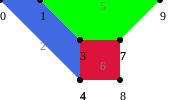

{(0, 0): 0, (2, 2): 1, (2, 4): 2, (3, 0): 3, (3, 3): 4, (4, 2): 5, (4, 4): 6, (4, 6): 7, (6, 0): 8, (6, 6): 9, (6, 8): 10, (7, 3): 11, (7, 7): 12, (8, 0): 13, (8, 6): 14, (8, 8): 15, (10, 2): 16, (10, 4): 17, (11, 0): 18, (11, 3): 19, (12, 2): 20, (12, 4): 21, (14, 0): 22, (14, 2): 23, (16, 0): 24}
qubit num: data 17, ancilla 8 total 25
est num qubits = 25


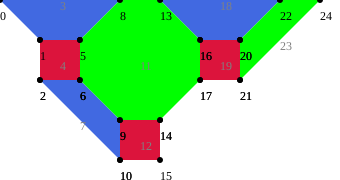

{(0, 0): 0, (2, 0): 1, (2, 2): 2, (4, 2): 3, (4, 4): 4, (5, 0): 5, (5, 3): 6, (6, 2): 7, (6, 4): 8, (8, 0): 9, (8, 6): 10, (8, 8): 11, (9, 3): 12, (9, 7): 13, (10, 0): 14, (10, 6): 15, (10, 8): 16, (10, 10): 17, (12, 2): 18, (12, 4): 19, (12, 10): 20, (12, 12): 21, (13, 0): 22, (13, 3): 23, (13, 7): 24, (13, 11): 25, (14, 2): 26, (14, 4): 27, (14, 10): 28, (14, 12): 29, (16, 0): 30, (16, 6): 31, (16, 8): 32, (17, 3): 33, (17, 7): 34, (18, 0): 35, (18, 6): 36, (18, 8): 37, (20, 2): 38, (20, 4): 39, (20, 6): 40, (21, 0): 41, (21, 3): 42, (22, 2): 43, (22, 4): 44, (24, 0): 45}
qubit num: data 31, ancilla 15 total 46
est num qubits = 46


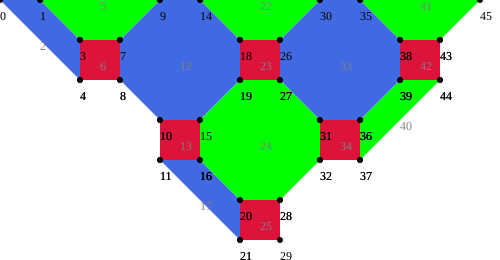

{(0, 0): 0, (2, 2): 1, (2, 4): 2, (3, 0): 3, (3, 3): 4, (4, 2): 5, (4, 4): 6, (4, 6): 7, (6, 0): 8, (6, 6): 9, (6, 8): 10, (7, 3): 11, (7, 7): 12, (8, 0): 13, (8, 6): 14, (8, 8): 15, (10, 2): 16, (10, 4): 17, (10, 10): 18, (10, 12): 19, (11, 0): 20, (11, 3): 21, (11, 7): 22, (11, 11): 23, (12, 2): 24, (12, 4): 25, (12, 10): 26, (12, 12): 27, (12, 14): 28, (14, 0): 29, (14, 6): 30, (14, 8): 31, (14, 14): 32, (14, 16): 33, (15, 3): 34, (15, 7): 35, (15, 11): 36, (15, 15): 37, (16, 0): 38, (16, 6): 39, (16, 8): 40, (16, 14): 41, (16, 16): 42, (18, 2): 43, (18, 4): 44, (18, 10): 45, (18, 12): 46, (19, 0): 47, (19, 3): 48, (19, 7): 49, (19, 11): 50, (20, 2): 51, (20, 4): 52, (20, 10): 53, (20, 12): 54, (22, 0): 55, (22, 6): 56, (22, 8): 57, (22, 10): 58, (23, 3): 59, (23, 7): 60, (24, 0): 61, (24, 6): 62, (24, 8): 63, (26, 2): 64, (26, 4): 65, (27, 0): 66, (27, 3): 67, (28, 2): 68, (28, 4): 69, (30, 0): 70, (30, 2): 71, (32, 0): 72}
qubit num: data 49, ancilla 24 total 73
est num qubits = 7

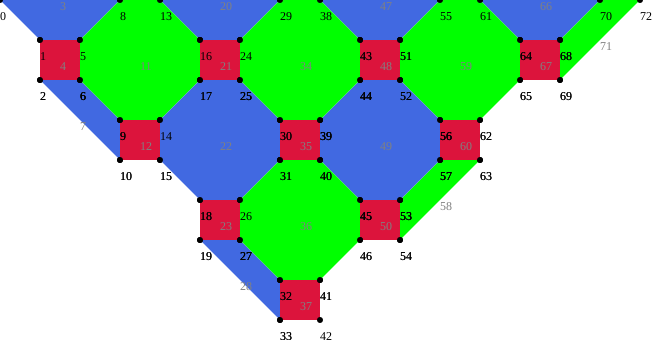

In [8]:
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }


def draw_tiles(layout):
    width = max(x for tile in layout for x,y in tile.qubits)
    height = max(y for tile in layout for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20+20, height*20+20))
    qs = set()
    ans = set()
    for tile in layout:
        for q in tile.qubits:
            qs.add(q)
        ans.add(tile.ancilla)
    
    sorted_q_a = sorted(qs | ans)
    qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
    #print(qa_index_map)
    for tile in layout:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        #drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        drawing.add(drawing.text(str(qa_index_map[tile.ancilla]),insert=(tile.ancilla[0]*20, tile.ancilla[1]*20+10), fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
            drawing.add(drawing.text(str(qa_index_map[(x,y)]),insert=(x*20, y*20+20), fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))
    
def draw_tiles_indexed(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20+20, height*20+20))
    sorted_q_a = sorted(CC.qubits | CC.ancilla)
    qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        #drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        drawing.add(drawing.text(str(qa_index_map[tile.ancilla]),insert=(tile.ancilla[0]*20, tile.ancilla[1]*20+10), fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
            drawing.add(drawing.text(str(qa_index_map[(x,y)]),insert=(x*20, y*20+20), fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

for d in [3,5,7,9]:
    CC = ColorCodeCircuit488Debug(d,2,noise=None, basis='Z')
    layout = CC._generate_layout(d)
    #print(layout)
    print(CC.qtoid)
    #print(CC.get_circuit())
    print(f"qubit num: data {len(CC.qubits)}, ancilla {len(CC.ancilla)} total {len(CC.qubits | CC.ancilla)}")
    print(f"est num qubits = {(3*(d**2)+6*d-5)//4}")
    draw_tiles(layout)

In [35]:
import os
import stim

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\color_code_experiments
Qubit with error index: 0
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 1
Detectors flipped: True
-----------------------------

Qubit with error index: 2
Detectors flipped: False
-----------------------------

Qubit with error index: 3
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 4
Detectors flipped: True
-----------------------------

Qubit with error index: 5
Detectors flipped: False
-----------------------------

Qubit with error index: 6
Detectors flipped: False
-----------------------------

Qubit with error index: 7
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 8
Detectors flipped: True
-----------------------------

Qubit with error index: 9
Detectors flipped: True
-----------------------------

Qubit wi

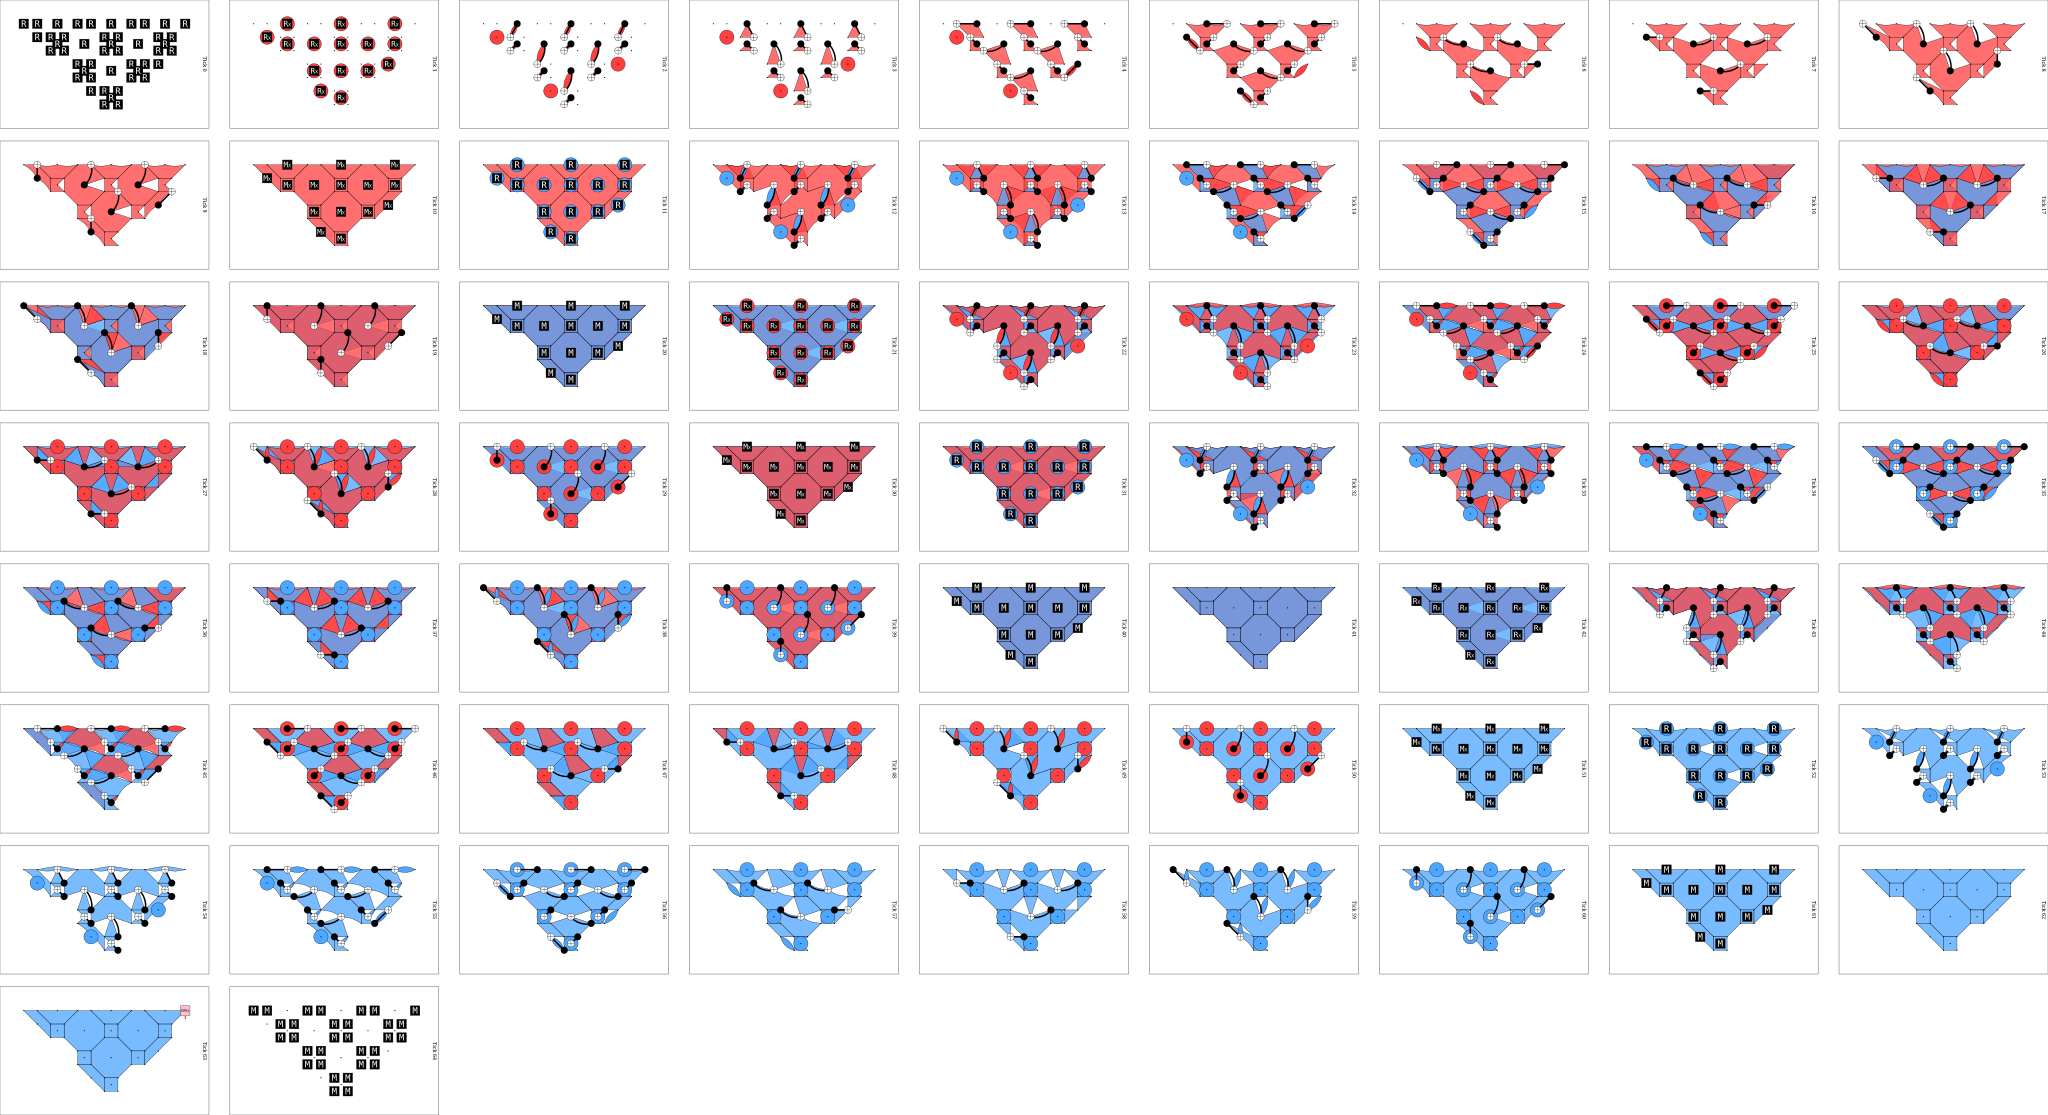

In [84]:

# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
#os.chdir('./color_code_experiments')
print(os.getcwd())

with open("singleerrorcirc.txt") as f:
    r = f.read()

for i in range(46):
    r_new = r.replace("X_ERROR(1)", f"X_ERROR(1) {i}")
    circ = stim.Circuit(r_new)
    dem = circ.detector_error_model()

    #explanation = circ.explain_detector_error_model_errors(
    #    dem_filter=dem, 
    #    reduce_to_one_representative_error=True
    #)
    #print(explanation)

    dem = circ.detector_error_model()

    sampler = stim.CompiledDetectorSampler(circ)
    # sample once with seed to see detectors:
    dets, obs = sampler.sample(shots=10, separate_observables=True)
    
    print(f"Qubit with error index: {i}")
    print("Detectors flipped:", dets.any())
    if (obs.any()):
        print("Observables flipped:", obs.any())
    
    print("-----------------------------\n")

circ.diagram("detslice-with-ops-svg")

In [54]:

circuit = ColorCodeCircuit488Debug(distance=5, rounds=5, noise=0.001, basis='X').get_circuit()

"""circuit=stim.Circuit.generated(
                    rounds=5,
                    distance=3,
                    after_clifford_depolarization=1e-3,
                    code_task=f'surface_code:rotated_memory_x',
                )"""
try:
    shortest_error = circuit.search_for_undetectable_logical_errors(
        dont_explore_detection_event_sets_with_size_above=4, 
        dont_explore_edges_with_degree_above=4,
        dont_explore_edges_increasing_symptom_degree=False
    )
    print(f"True Effective Distance: {len(shortest_error)}")
    
    # Print the exact physical qubits involved in the catastrophic failure
    for fault in shortest_error:
        print(fault)
        
except ValueError as e:
    print("Could not find a logical error, or search space too complex.")
#circuit_errors = circ.explain_detector_error_model_errors()
#print(circuit_errors)

True Effective Distance: 3
ExplainedError {
    dem_error_terms: D8[coords 3,0,1,2] D13[coords 11,0,1,2]
    CircuitErrorLocation {
        flipped_pauli_product: Z13[coords 8,0]*Z11[coords 7,3]
        Circuit location stack trace:
            (after 18 TICKs)
            at instruction #105 (DEPOLARIZE2) in the circuit
            at targets #3 to #4 of the instruction
            resolving to DEPOLARIZE2(0.001) 13[coords 8,0] 11[coords 7,3]
    }
    CircuitErrorLocation {
        flipped_pauli_product: Z11[coords 7,3]
        Circuit location stack trace:
            (after 17 TICKs)
            at instruction #101 (DEPOLARIZE2) in the circuit
            at targets #1 to #2 of the instruction
            resolving to DEPOLARIZE2(0.001) 5[coords 4,2] 11[coords 7,3]
    }
}
ExplainedError {
    dem_error_terms: D8[coords 3,0,1,2] L0
    CircuitErrorLocation {
        flipped_pauli_product: Z3[coords 3,0]*Z0[coords 0,0]
        Circuit location stack trace:
            (after 26 TICK

In [38]:
dem = test_circuit.detector_error_model(decompose_errors=True)
print(dem.shortest_graphlike_error())
dem = circ.detector_error_model(decompose_errors=False)
print(dem)

NameError: name 'test_circuit' is not defined

In [39]:
#sampling
import chromobius
import numpy as np

CC_samp = ColorCodeCircuit488Debug(5,12,0.01)
samp_circuit = CC_samp.get_circuit()

sampler = samp_circuit.compile_detector_sampler()
dem = samp_circuit.detector_error_model()
decoder = chromobius.compile_decoder_for_dem(dem)

dets, actual_obs = sampler.sample(
    shots=50,
    separate_observables=True,
    bit_packed=True,
)

predicted_obs = decoder.predict_obs_flips_from_dets_bit_packed(dets)

mistakes = np.count_nonzero(np.any(predicted_obs != actual_obs, axis=1))
print(f'{mistakes=}')
print(predicted_obs)


mistakes=18
[[1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]]


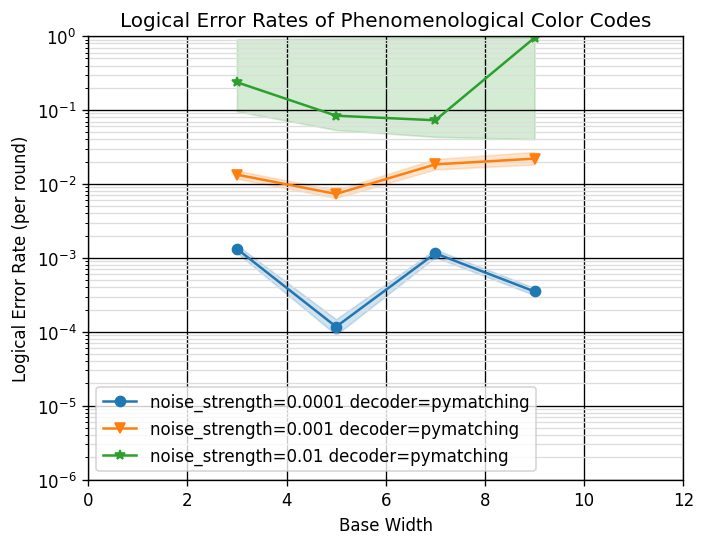

In [38]:
#plotting
import matplotlib.pyplot as plt
import os
import sinter

tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit488Debug(d,r,p).get_circuit(),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3,5,7,9]
    for r in [d*4]
    for b in ['Z']
    for p in [0.001,0.0001,0.01]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=1000,
    print_progress=False,
    decoders=['pymatching'],
    #custom_decoders=chromobius.sinter_decoders(),
)

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['d'],
    group_func=lambda stat: f"""noise_strength={stat.json_metadata['p']} decoder={stat.decoder}""",
    failure_units_per_shot_func=lambda stat: stat.json_metadata['r'],
)
ax.set_ylim(1e-6, 1e-0)
ax.set_xlim(0, 12)
ax.semilogy()
ax.set_title("Logical Error Rates of Phenomenological Color Codes")
ax.set_xlabel("Base Width")
ax.set_ylabel("Logical Error Rate (per round)")
ax.grid(which='major', color='#000000')
ax.grid(which='minor', color='#DDDDDD')
ax.legend()
fig.set_dpi(120)  # Show it bigger



stats = [sinter.TaskStats(strong_id='7e46789f58a331bbe5e18e95c858299236f92318382721e13a9b4b4861201780', decoder='chromobius', json_metadata={'d': 3, 'p': 0.0001, 'r': 12, 'b': 'Z'}, shots=100000, errors=260, seconds=0.3120000000053551), sinter.TaskStats(strong_id='ed63be6fc27454f9c92a0693e054f89c241ec739306ef91f5fe6f5518b5a3cc1', decoder='chromobius', json_metadata={'d': 3, 'p': 0.001, 'r': 12, 'b': 'Z'}, shots=17681, errors=1053, seconds=0.375), sinter.TaskStats(strong_id='4cb825aaff0f5187341595982a6f47f8127f834c4d5836b33252fa5aa5ff56fd', decoder='chromobius', json_metadata={'d': 3, 'p': 0.01, 'r': 12, 'b': 'Z'}, shots=2321, errors=1153, seconds=0.34400000001187436), sinter.TaskStats(strong_id='168abfcb7ee7beb7fa16934ce141ee8dbcb724afbf581e5e7c670b9c8ce6458f', decoder='chromobius', json_metadata={'d': 5, 'p': 0.001, 'r': 20, 'b': 'Z'}, shots=15633, errors=1054, seconds=2.015999999974156), sinter.TaskStats(strong_id='69150fc00d5d4da7189adf90b21ec1d5b6d190cf0e64ff072e09fca7c4c92eac', de

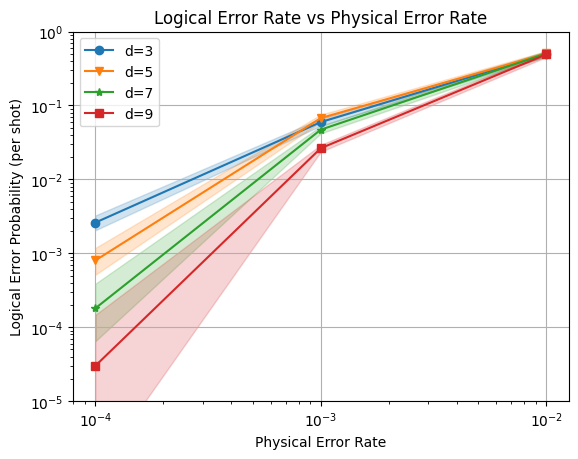

In [55]:
import matplotlib.pyplot as plt
import sinter

tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit488Debug(d,r,p, basis='X').get_circuit(),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3,5,7,9]
    for r in [d*4]
    for b in ['Z']
    for p in [0.001,0.0001,0.01]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=1000,
    print_progress=False,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)
print(f'stats = {stats}')
# Render a matplotlib plot of the data.
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stat: f"d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend(title='488 Code Distance')
ax.legend()
for stat in stats:
    if stat.json_metadata['d']==11 or stat.json_metadata['d']==3:
        print(stat)
        print("--------------------------------------------")
# Save to file and also open in a window.
#fig.savefig('plot.png')
plt.show()

Starting 4 workers...
80 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                    
        1 chromobius   ?     100000        1000 d=3,p=0.0001,r=12                
        1 chromobius   ?     100000        1000 d=3,p=0.00012742749857031334,r=12
        1 chromobius   ?      98703         992 d=3,p=0.0001623776739188721,r=12 
        1 chromobius   ?     100000        1000 d=3,p=0.00020691380811147902,r=12
        0 chromobius ?·∞     100000        1000 d=3,p=0.00026366508987303583,r=12
        0 chromobius ?·∞     100000        1000 d=3,p=0.0003359818286283781,r=12 
        0 chromobius ?·∞     100000        1000 d=3,p=0.00042813323987193956,r=12
        0 chromobius ?·∞     100000        1000 d=3,p=0.000545559478116852,r=12  
        0 chromobius ?·∞     100000        1000 d=3,p=0.0006951927961775605,r=12 
        0 chromobius ?·∞     100000        1000 d=3,p=0.0008858667904100823,r=12 
        0 chromobius ?·∞     100000        1000 d=3,p=0.00112

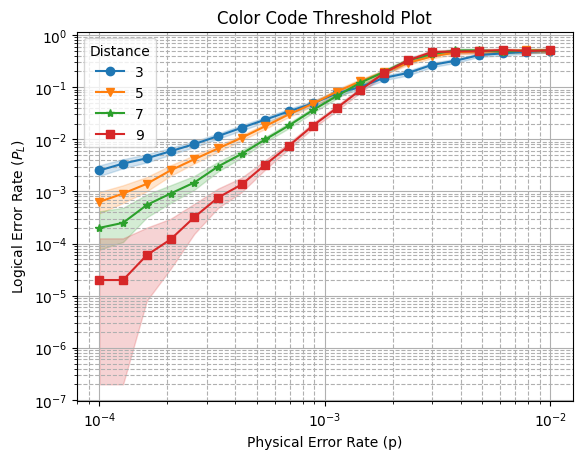

In [56]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np

def generate_plot():
    distances = [3, 5, 7, 9]
    noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01]
    noise_lvls = np.logspace(-4,-2,20)
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit488Debug(d,r,p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in distances
        for r in [d*4]
        for p in noise_lvls
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=100_000,
        max_errors=1000,
        print_progress=True,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    #plt.savefig("ImplCCThresholdPlot")
    plt.show()
generate_plot()